# Applied ML Final Project: Predicting Lending Approval Outcomes 💳
### Authors: Sam & Nishi

## Project Outline & Checklist
**1. Setup**
- [x] Define the problem and target variable  
- [x] Load dataset and inspect structure, data types  
 
**2. Cleaning & Exploratory Data Analysis**
- [x] Handle missing values  
- [x] Confirm proper data types  
- [x] Descriptive statistics and distributions  
- [x] Correlation analysis + target relationships  
- [x] Visualize numeric and categorical predictors  
- [x] Identify and review potential outliers  

**3. Preprocessing**
- [ ] Remove or cap extreme outliers (if appropriate)  
- [ ] Encode categorical variables  
- [ ] Scale/normalize numeric features  
- [ ] Train/test split (stratified)

**4. Supervised Modeling**
- [ ] Baseline model: Logistic Regression  
- [ ] Train additional models (Random Forest, XGBoost, SVM)  
- [ ] Hyperparameter tuning (GridSearch or RandomizedSearch)  
- [ ] Address class imbalance (optional: class weights, SMOTE)  

**5. Unsupervised Learning (Clustering)**
- [ ] Apply k-means or hierarchical clustering  
- [ ] Visualize clusters (PCA or t-SNE)  
- [ ] Analyze cluster characteristics  
- [ ] Compare clusters to loan approval outcomes  
- [ ] Discuss how clustering complements supervised results  

**6. Evaluation**
- [ ] Test-set metrics: accuracy, precision, recall, F1, ROC AUC  
- [ ] Confusion matrix + error analysis  
- [ ] Feature importance / interpretability  
- [ ] Compare supervised predictions with cluster patterns  

**7. Final Output**
- [ ] Compare and select best model  
- [ ] Summarize key findings and insights  
- [ ] Integrate supervised + unsupervised conclusions  
- [ ] Save final notebook and model artifacts  

## Dataset Metadata

In [114]:
import json # Needed to look at metadata

with open('loan-approval-classification-data-metadata.json') as f:
    meta = json.load(f)

In [115]:
print("Dataset Name:", meta["name"])
print("Description:", meta["description"])
print("Author:", meta["creator"]["name"])
print("Files Included:")

for item in meta["distribution"]:
    print(f"- {item['name']} ({item['encodingFormat']})")

Dataset Name: Loan Approval Classification Dataset
Description: ## 1. **Data Source**
This dataset is a synthetic version inspired by the original [Credit Risk dataset on Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset) and enriched with additional variables based on [Financial Risk for Loan Approval data](https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval). SMOTENC was used to simulate new data points to enlarge the instances. The dataset is structured for both categorical and continuous features.

## 2. **Metadata**
The dataset contains 45,000 records and 14 variables, each described below:

| Column                         | Description                                          | Type        |  
|--------------------------------|------------------------------------------------------|-------------|  
| `person_age`                   | Age of the person                                    | Float       |  
| `person_gender`            

## Imports

In [116]:
# Basic mathematical imports and visualization packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split
from sklearn.model_selection import train_test_split  # To split training and testing data

# Preprocessing + pipeline tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Scaling/normalizing, encoding categorical variables
from sklearn.compose import ColumnTransformer                     # Different transforms per column type
from sklearn.pipeline import Pipeline                             # Full ML pipeline

# Metrics
from sklearn.metrics import ( 
    precision_score,
    recall_score, 
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Models
from sklearn.linear_model import LogisticRegression          # Logistic regression ml model
from sklearn.ensemble import RandomForestClassifier          # Random forest ml model
from xgboost import XGBClassifier                            # Gradient-boosted decision tree ml model

## Exporatory Data Analysis

In [117]:
# Path
path = "https://raw.githubusercontent.com/samstrc/AppliedML_FinalProj/98d4784b6eb1d42a68e0283f86777bdb03bb2afc/loan_data.csv"
df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [118]:
# Check for missing data
missing_sum = df.isna().sum().sum()
if (missing_sum != 0):
    print(f"There are {missing_sum} missing values in the dataset!")
else:
    print("There are no missing values in this dataset.")

There are no missing values in this dataset.


### Target/Response Variable Checks

In [119]:
# Check for a class imbalance
class_imbalance = df["loan_status"].value_counts(normalize=True)
class_imbalance

loan_status
0   0.78
1   0.22
Name: proportion, dtype: float64

It is shown that the class imbalance is rather significant, meaning the number of applications that were approved make up 22% of all observations in the data. SMOTE must be considered or other oversampling methods. Reliance on accuracy alone is not suiteable for this dataset. F1, precision/recall, ROC/AUC, and confusion matrix statistics should be analyzed closely.

### Numeric Predictor Checks

In [120]:
pd.set_option('display.float_format', lambda x: f"{x:,.2f}") # Change numeric variable expression 

df_numeric = df.select_dtypes(include="number")
df_numeric

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.00,"71,948.00",0,"35,000.00",16.02,0.49,3.00,561,1
1,21.00,"12,282.00",0,"1,000.00",11.14,0.08,2.00,504,0
2,25.00,"12,438.00",3,"5,500.00",12.87,0.44,3.00,635,1
3,23.00,"79,753.00",0,"35,000.00",15.23,0.44,2.00,675,1
4,24.00,"66,135.00",1,"35,000.00",14.27,0.53,4.00,586,1
...,...,...,...,...,...,...,...,...,...
44995,27.00,"47,971.00",6,"15,000.00",15.66,0.31,3.00,645,1
44996,37.00,"65,800.00",17,"9,000.00",14.07,0.14,11.00,621,1
44997,33.00,"56,942.00",7,"2,771.00",10.02,0.05,10.00,668,1
44998,29.00,"33,164.00",4,"12,000.00",13.23,0.36,6.00,604,1


In [121]:
df_numeric.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,"45,000.00","45,000.00","45,000.00","45,000.00","45,000.00","45,000.00","45,000.00","45,000.00","45,000.00"
mean,27.76,"80,319.05",5.41,"9,583.16",11.01,0.14,5.87,632.61,0.22
std,6.05,"80,422.50",6.06,"6,314.89",2.98,0.09,3.88,50.44,0.42
min,20.00,"8,000.00",0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,"47,204.00",1.00,"5,000.00",8.59,0.07,3.00,601.00,0.00
50%,26.00,"67,048.00",4.00,"8,000.00",11.01,0.12,4.00,640.00,0.00
75%,30.00,"95,789.25",8.00,"12,237.25",12.99,0.19,8.00,670.00,0.00
max,144.00,"7,200,766.00",125.00,"35,000.00",20.00,0.66,30.00,850.00,1.00


A few things to note here: 
- The middle 50% of people applying for a loan were between the ages of 24 and 30
- The middle 50% of loan interest rates were between 8.59-12.99%, with the average being 11%. 

Response Variable:
- The mean is 22, also showing the class imbalance from a different angle.

Skew: 
- Income is extremely right skewed
- Loan ammount is extremly right skewed
- **Both should be visualized for further inspection**

Outliers:
- A few very rich people applied for a loan.
- Someone was recorded to of had 125 years of work expierience?
- Someone was recorded to of had 30 years of credit history. It may be worth checking their age to make sure this is accurate. 

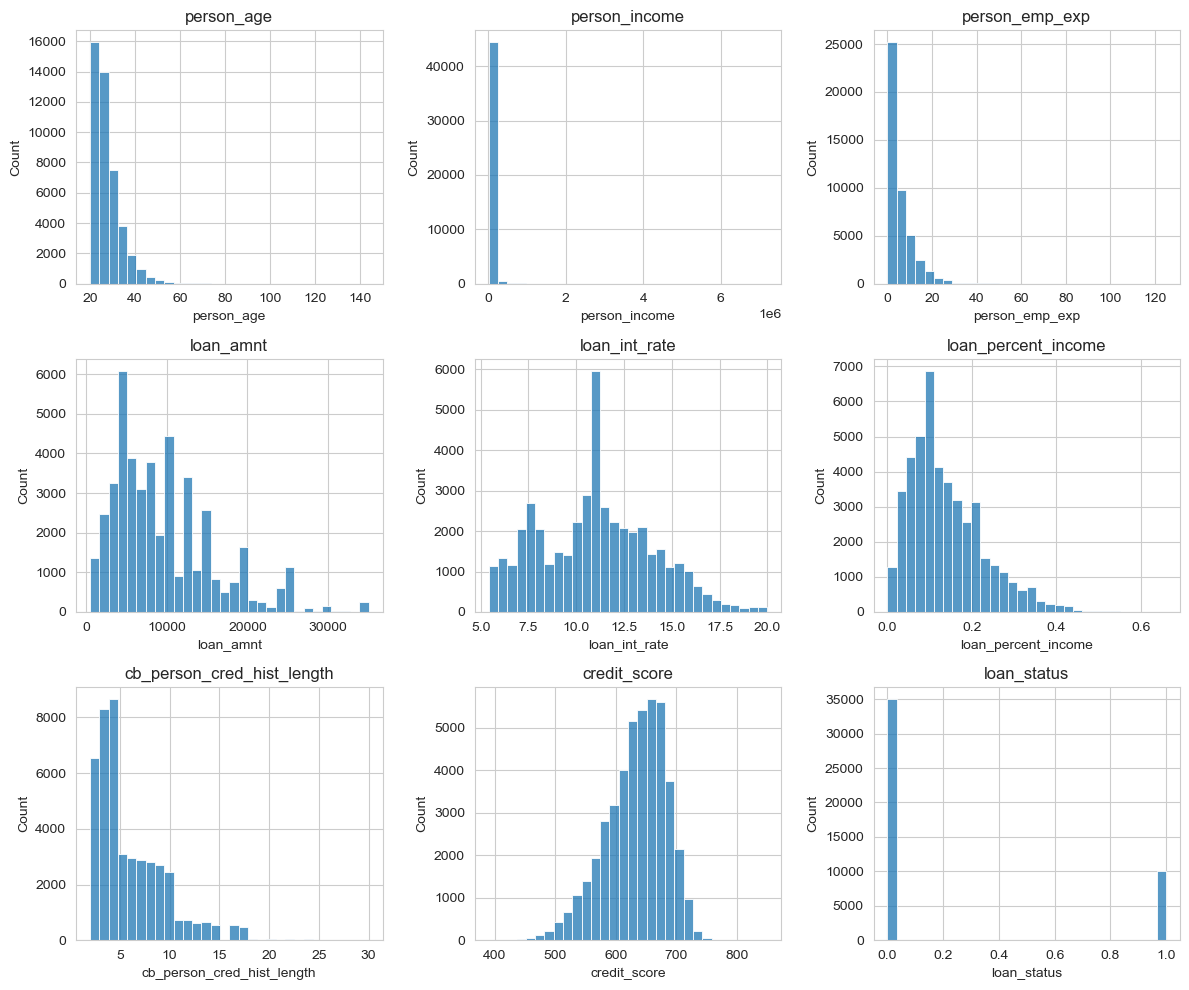

In [122]:
# Visualize all numeric predictors
# Histograms 
num_cols = df_numeric.columns

plt.figure(figsize=(12, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.histplot(df_numeric[col], bins=30, kde=False)
    plt.title(col)

plt.tight_layout()
plt.show()

The numeric predictors show substantial right skew across most variables in the dataset. Person income, employment experience, loan percent income, and age all display heavy right tails and a concentration of values near the lower end, with several extreme outliers, such as incomes in the millions, ages above 100, and employment experience exceeding 100 years. These outliers suggest either data-entry issues or synthetic artifacts and may require clipping or transformation before modeling.

Loan interest rate and credit score are among the cleanest distributions, with credit score showing a nearly bell-shaped distribution and loan interest rates centered around 8–13%. Loan amount is moderately skewed but shows a wide spread across applicants.

The target variable **loan_status** is evidently heavily imbalanced here as well, with approximately **78%** denials and **22%** approvals.

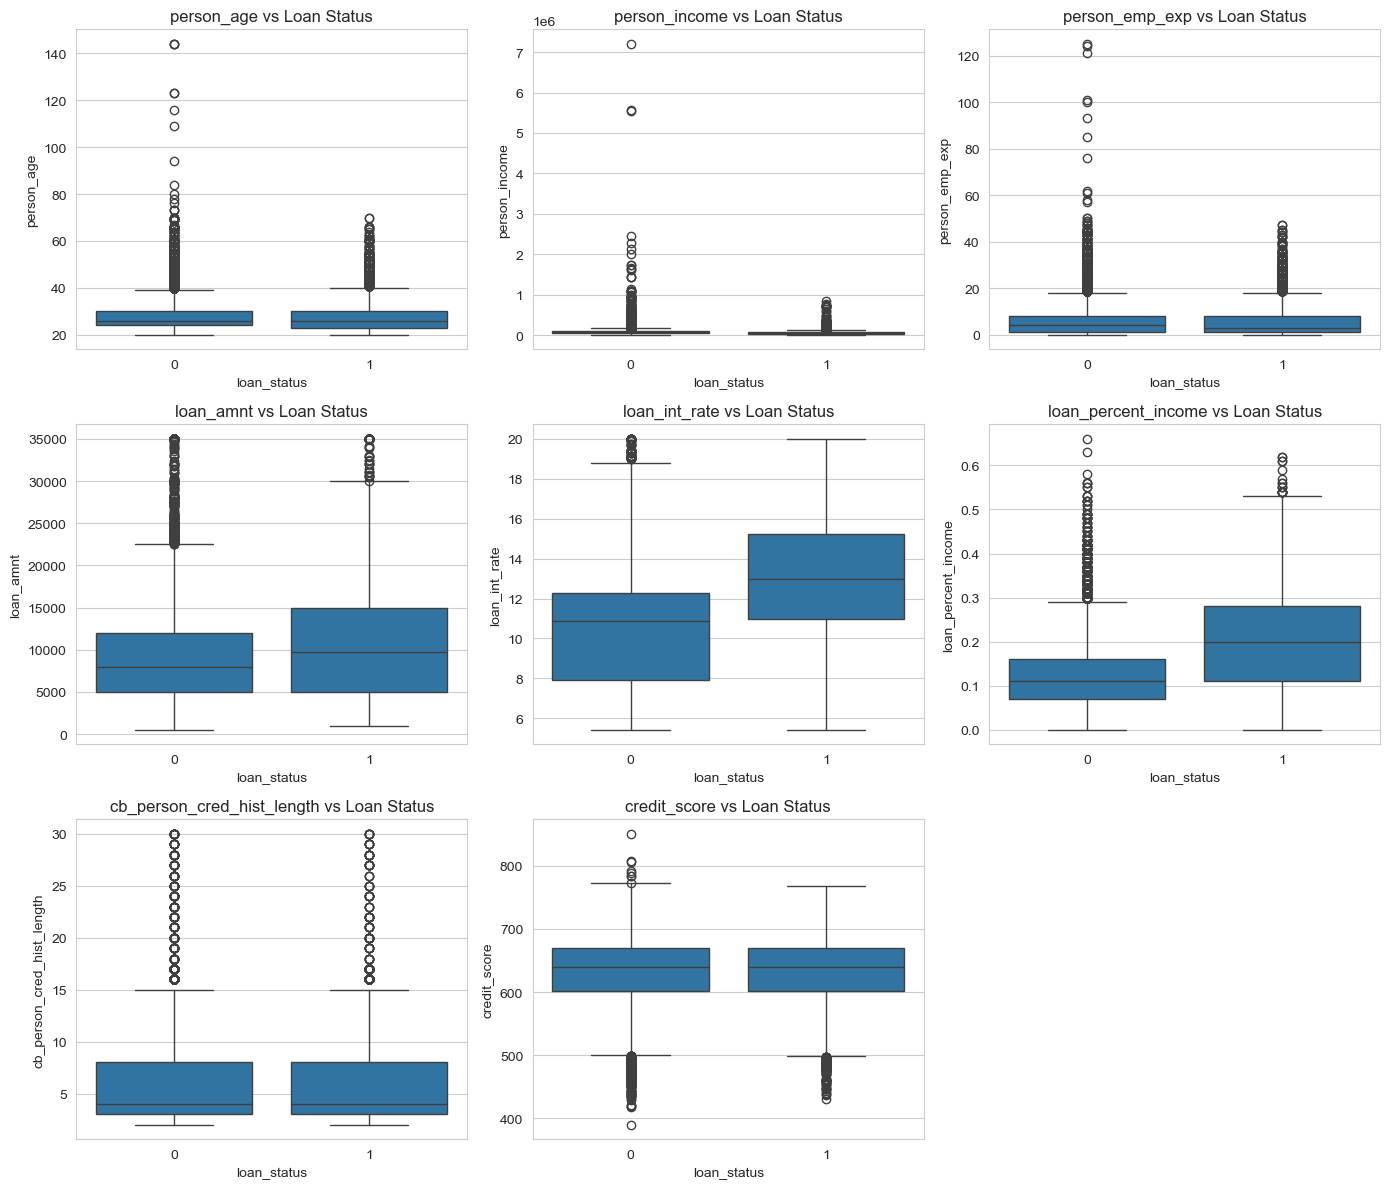

In [123]:
# Boxplots to visualize against target variable
# Select numeric predictors but exclude the target column
num_cols = df_numeric.columns.drop("loan_status")

plt.figure(figsize=(14, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.boxplot(data=df, x="loan_status", y=col)
    plt.title(f"{col} vs Loan Status")
    plt.tight_layout()

plt.show()

Box plots that show larger separations between the two loan_status groups indicate that the numeric predictor differs meaningfully between approved and denied applicants. This suggests the variable may be a strong predictor of the target.

The variables showing the clearest separation are:
-	loan_int_rate
-	loan_percent_income
-	loan_amnt (moderate separation)

Demographic variables like age and employment experience show little class separation and are likely weak contributors.

Correlations of each predictor and the response variable:
 person_income                -0.14
person_age                   -0.02
person_emp_exp               -0.02
cb_person_cred_hist_length   -0.01
credit_score                 -0.01
loan_amnt                     0.11
loan_int_rate                 0.33
loan_percent_income           0.38
loan_status                   1.00
Name: loan_status, dtype: float64


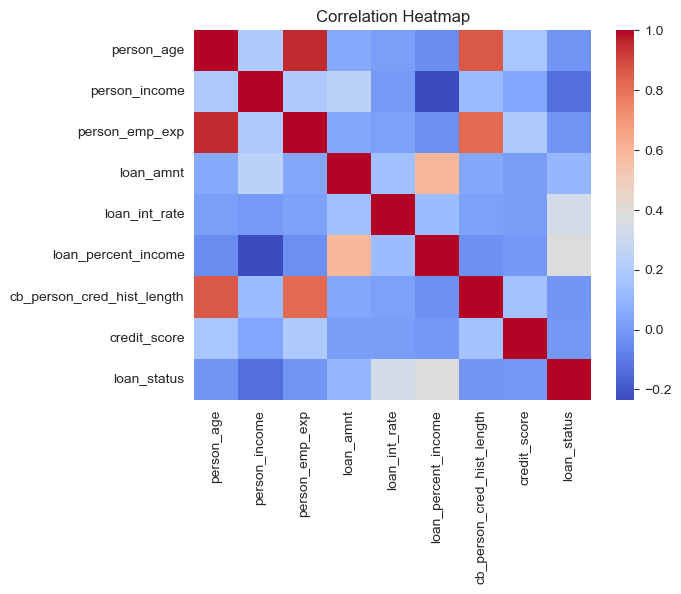

In [124]:
sns.heatmap(df_numeric.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
print("Correlations of each predictor and the response variable:\n", df_numeric.corr()["loan_status"].sort_values())

In [125]:
# Note high correlations for future investigation
corr_matrix = df_numeric.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Threshold
threshold = 0.6

# Find pairs above the threshold
high_corr = [(col1, col2, upper.loc[col1, col2])
             for col1 in upper.columns
             for col2 in upper.columns
             if upper.loc[col1, col2] > threshold]

high_corr

[('person_age', 'person_emp_exp', 0.9544121607878328),
 ('person_age', 'cb_person_cred_hist_length', 0.86198455770491),
 ('person_emp_exp', 'cb_person_cred_hist_length', 0.8242715421191774)]

Highly correlated variables might confuse linear models, or not add much to other models. It may be useful to remember these correlations when considering dropping columns. 

### Categorical Variable Checks

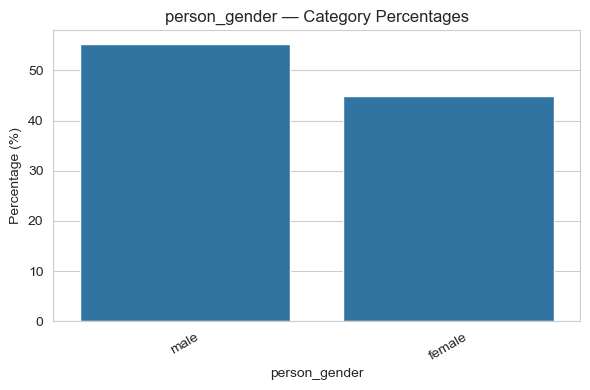

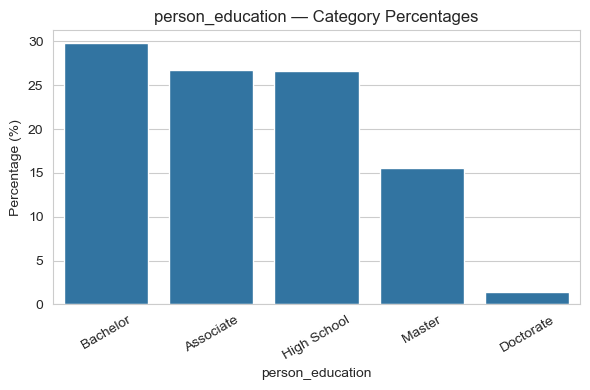

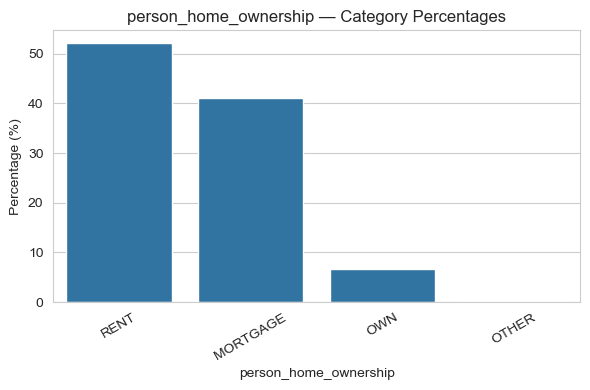

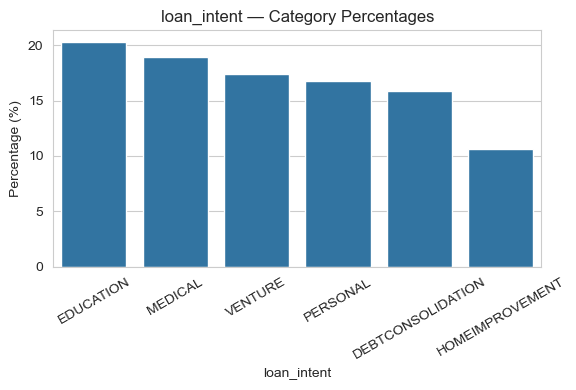

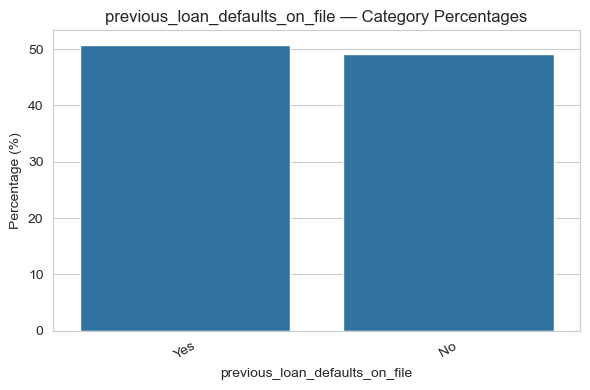

In [126]:
# Extract categorical columns 
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("percent")
        .reset_index()
        .pipe(lambda d: sns.barplot(data=d, x=col, y="percent"))
    )
    plt.title(f"{col} — Category Percentages")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

The categorical predictors show healthy and well-distributed category frequencies across most variables, with slight imbalances in homeownership and rare categories like Doctorate education and Other ownership. Gender, education, and loan intent are fairly balanced, while previous loan defaults are almost evenly split, suggesting these features may meaningfully contribute to loan approval predictions.

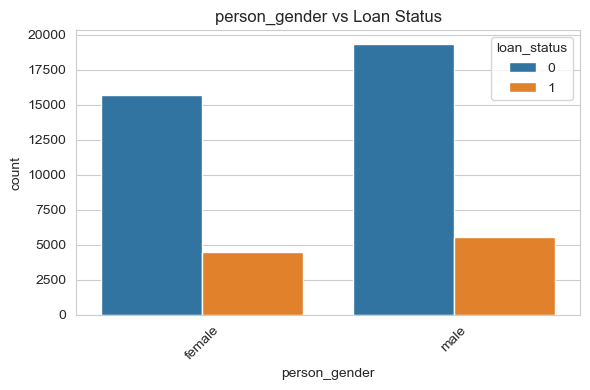

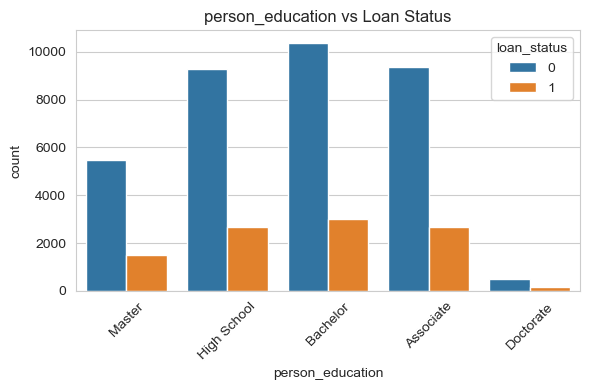

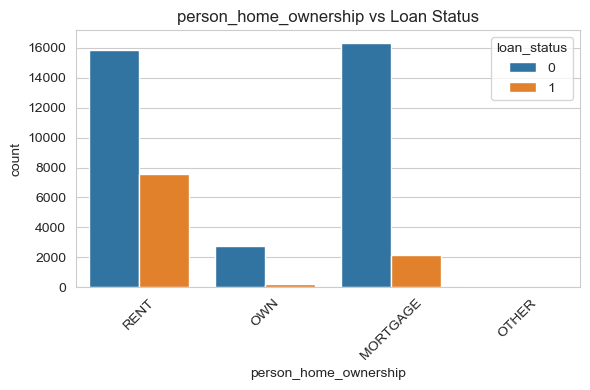

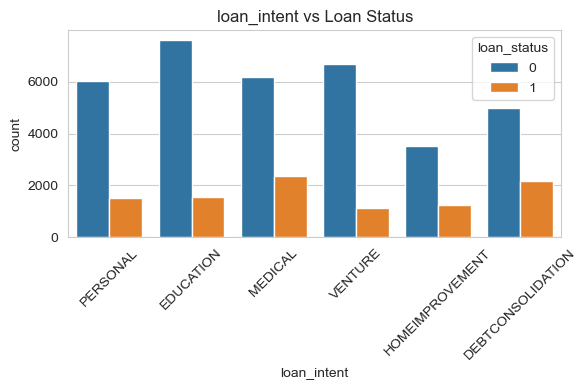

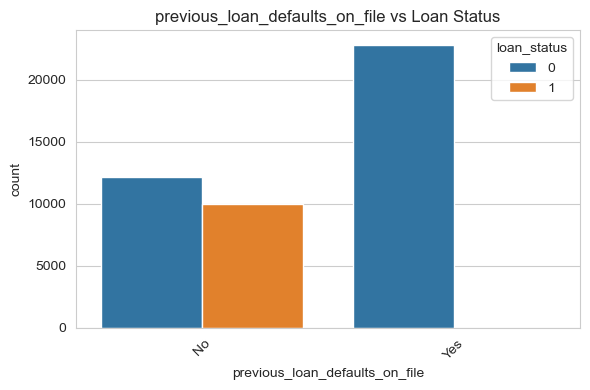

In [127]:
# Visualize each category against the target
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="loan_status")
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The categorical variables reveal several patterns in loan approval behavior. Gender shows virtually no meaningful difference, with male and female applicants experiencing nearly identical approval and denial rates. Education level also has only mild effects. Bachelor’s, Associate, and High School groups behave similarly, while Master’s applicants appear slightly more likely to be approved, though the difference is small and Doctorate observations are too rare to interpret. Home ownership stands out as a much stronger predictor. Renters and mortgage holders receive substantially more approvals compared to those who list “own” or “other,” suggesting lenders view the former groups as more stable or lower risk. Loan intent also demonstrates some variation, with education, medical, and venture-related loans seeing higher approval counts, while home improvement loans tend to receive fewer approvals overall. The clearest signal comes from previous defaults: applicants with no prior defaults receive many approvals, whereas those with defaults on file are almost always denied. Overall, home ownership, loan intent, and especially prior default history appear to carry the strongest predictive power among the categorical variables.

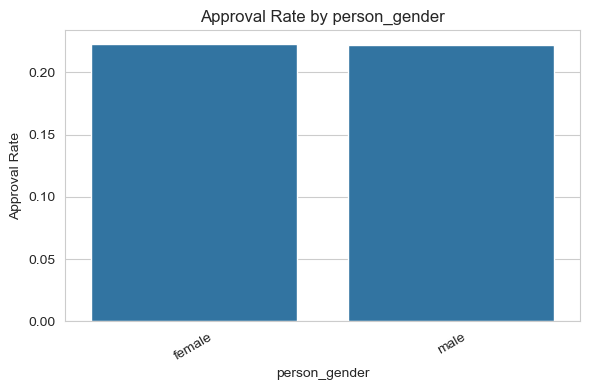

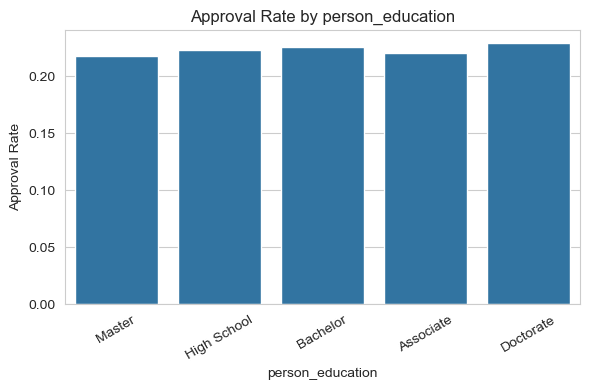

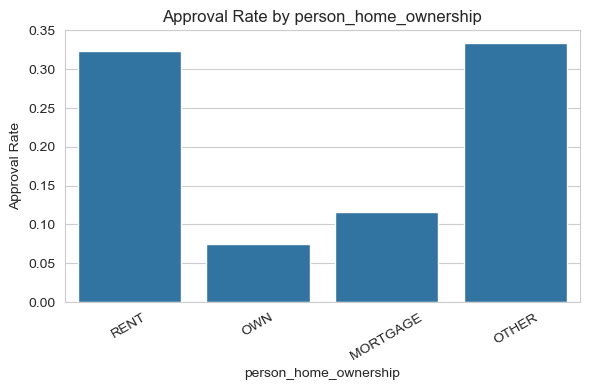

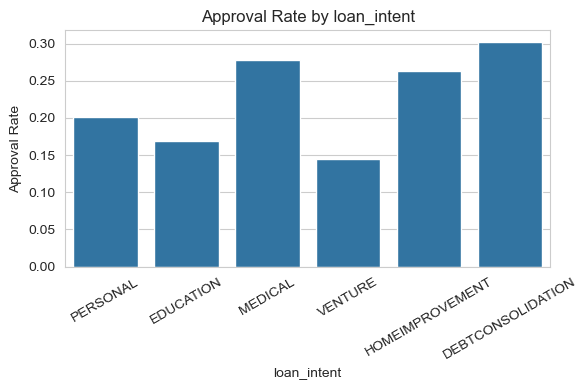

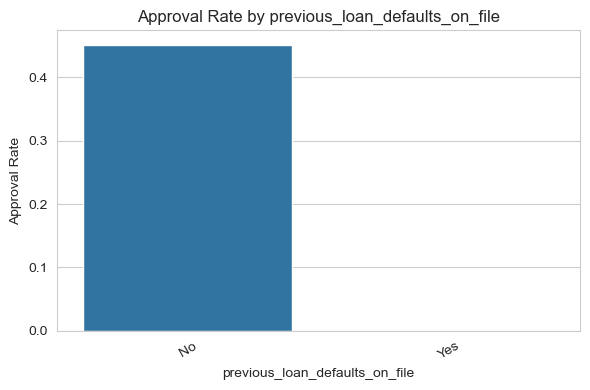

In [128]:
# Approval rate per category
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df,
        x=col,
        y="loan_status",   # mean approval rate per category
        estimator=np.mean,
        errorbar=None
    )
    plt.title(f"Approval Rate by {col}")
    plt.ylabel("Approval Rate")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

The approval rate visualizations give a clearer picture of how each categorical variable relates to loan approval likelihood.

Gender again shows no material effect—males and females have nearly identical approval rates, both hovering slightly above 0.22. Education levels also produce very similar approval rates across categories; while Doctorate appears slightly higher, the category is too small to draw strong conclusions, and the remaining groups cluster tightly around the same range. This suggests that education level has minimal predictive influence in this dataset.

Home ownership, however, shows substantial variation. Renters and those classified as “OTHER” have significantly higher approval rates (around 0.32–0.34), while applicants who “OWN” their home outright have the lowest approval rate at roughly 0.07. Mortgage holders fall in the middle. This reinforces the earlier finding that home ownership status carries meaningful signal and may reflect stability, risk, or lender preferences embedded in the synthetic data.

Loan intent also shows noticeable differences in approval probability. Medical and debt consolidation loans receive the highest approval rates (around 0.28–0.30), while venture loans have the lowest rate at roughly 0.14. Personal, education, and home improvement loans fall in the mid-range. These patterns imply that the reason for the loan is tied-moderately-to approval likelihood.

Finally, previous loan defaults are by far the strongest categorical predictor. Applicants with no prior defaults show an approval rate near 0.45, whereas applicants with defaults on file have an approval rate close to zero. This extreme separation aligns with the earlier count-based analysis and indicates this variable will heavily influence model predictions.